# Following the LMC: centering along an orbit

This notebook follows the center of the LMC through the GC21 MWLMC5_b0 simulation with `nba.orbits.orbit`,
and compares two methods of `nba.com.CenterHalo`:

- `shrinking_sphere_numba`, the method for satellites, tracking the center from snapshot to snapshot;
- `mean_pos`, the mean position of the LMC particles, which stripped particles pull away from the center.

`min_potential` is not used: the snapshot potential is the total potential, so the lowest-potential LMC
particles are stripped particles in the MW's potential well, and its "center" follows the MW instead.

The snapshots are not public. To run the notebook, set `NBA_GC21_DIR` to the `MWLMC5_b0/out` folder, and
optionally `NBA_ORBIT_DIR` to where the orbit files go. Computing the orbits reads all 451 snapshots (about
1.5 hours, 6-7 GB of memory); once the files exist they are read instead.

In [1]:
%matplotlib inline
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from nba.ios import ReadGC21
from nba.orbits import orbit, read_orbit

CMAP = plt.get_cmap("magma").with_extremes(bad="black")  # empty pixels in black

## Configuration

In [2]:
path = os.environ.get("NBA_GC21_DIR", "<MWLMC5_b0/out folder>")
snapname = "MWLMC5_100M_b0_vir_OM3_G4_{:03d}.hdf5"
snapshots = range(451)
orbit_dir = os.environ.get("NBA_ORBIT_DIR", "lmc_orbits")
methods = ["shrinking_sphere_numba", "mean_pos"]
outfile = os.path.join(orbit_dir, "MWLMC5_b0_lmc_orbit_{method}.ecsv")

# Snapshots 400-450 were written after a restart that reset the header time to 0
# (8.0 in code units, 7.8 Gyr): time_offset adds it back
time_offset = lambda k: 8.0 if k >= 400 else 0.0

## Computing the orbits

`orbit` reads each snapshot once and applies both methods. The shrinking sphere uses the options recommended
for satellites:

- `softening=0.08`: the dark matter softening (kpc).
- `r0=15`: start each shrinking sphere within 15 kpc of the previous center, so that it does not jump to
  debris.
- `rvel_factor=5`: the velocity of the particles within 5 times the final radius.
- `min_density_ratio=0.01`: warn when the density in the final sphere falls below 1% of its initial value.

With `outfile`, each method's orbit is written to an ECSV file, with the diagnostics of every snapshot, the
parameters and the warnings.

In [3]:
os.makedirs(orbit_dir, exist_ok=True)
if not all(os.path.exists(outfile.format(method=m)) for m in methods):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # recorded in the files, shown below
        orbit(path, snapname, snapshots, halo="LMC", com_method=methods,
              softening=0.08, r0=15, rvel_factor=5, min_density_ratio=0.01, time_offset=time_offset,
              outfile=outfile, simulation={"name": "GC21 MWLMC5_b0", "dm_softening_kpc": 0.08})

orbits = {m: read_orbit(outfile.format(method=m)) for m in methods}
ss = orbits["shrinking_sphere_numba"]
ss[["snap", "t", "x", "y", "z", "vx", "vy", "vz", "radius", "npart", "density_ratio"]][::50]

snap,t,x,y,z,vx,vy,vz,radius,npart,density_ratio
,Gyr,kpc,kpc,kpc,km / s,km / s,km / s,kpc,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64
0,0.0,12.28370532641706,237.82852251263898,129.90564124197863,12.497372198093064,12.584796157172196,-76.83337501466244,0.3261381658134098,2410,1.0
50,0.9777923542981722,22.044763470098427,212.7317324223901,36.79413030761195,5.688174140043167,-70.98291992826381,-106.43440093053707,0.3279353464446705,2370,0.9673229420629673
100,1.9555847085963445,15.319869369593963,50.85702627157395,-53.85911582787669,-37.07085053463859,-300.71860422225836,20.327679730683872,0.3279353464446705,2014,0.8220204241834667
150,2.933377062894517,-10.288622536240554,-28.72232986927336,78.71124204923595,0.8554084260133323,62.321659032419525,54.92304598231992,0.3279353464446705,1585,0.6469227270758663
200,3.911169417192689,10.771450138748099,71.11965156063722,9.663446197963054,44.69871080907713,83.48428594790181,-267.2571025362783,0.3279353464446705,1603,0.6542694835978635
250,4.8889617714908615,12.99788556587888,-22.04685352214193,-84.18016927150323,-10.627519367879357,18.88565575424105,104.02844790713488,0.3449681487912379,1064,0.3730718358098288
300,5.866754125789034,30.92055335513654,116.50355432807758,-99.85165004484007,4.069335132917469,-59.71433055149476,-78.71010647195689,0.504324147020258,1008,0.11311470697793184
350,6.844546480087206,14.186900748067824,79.91173939111812,6.128015796699341,14.794761703938825,95.41395615663451,-32.66368477479152,1.0778821791518265,1000,0.011494073119534577


The files record how the orbit was computed: the parameters as used, the provenance of the code, and the
warnings raised during the run.

In [4]:
meta = ss.meta
print("nba", meta["provenance"]["nba_version"], meta["provenance"]["nba_commit"])
print("velocity:", meta["parameters"]["velocity_region"])
print(f"{len(meta['warnings'])} warnings:")
for w in meta["warnings"]:
    print(f"  {w['message']}")

nba 0.4.0.dev0 46001bb0f792c4aec150ee890c1f55c8bebc370c
velocity: particles within 5 times the final radius
6 warnings:
  snapshot 353, shrinking_sphere_numba: the density in the final sphere is 0.00945 of its value in the first snapshot (< 0.01); the satellite may have dissolved and its center may no longer be physical
  snapshot 376, shrinking_sphere_numba: for 3 snapshots the center moved inconsistently with its velocity (|dx - v dt| / (|v| dt) = 0.93 > 0.5); it may no longer follow a bound object
  snapshot 400, shrinking_sphere_numba: for 3 snapshots the center moved inconsistently with its velocity (|dx - v dt| / (|v| dt) = 1.4 > 0.5); it may no longer follow a bound object
  snapshot 416, shrinking_sphere_numba: for 3 snapshots the center moved inconsistently with its velocity (|dx - v dt| / (|v| dt) = 1.53 > 0.5); it may no longer follow a bound object
  snapshot 428, shrinking_sphere_numba: for 3 snapshots the center moved inconsistently with its velocity (|dx - v dt| / (|v| d

## The orbits

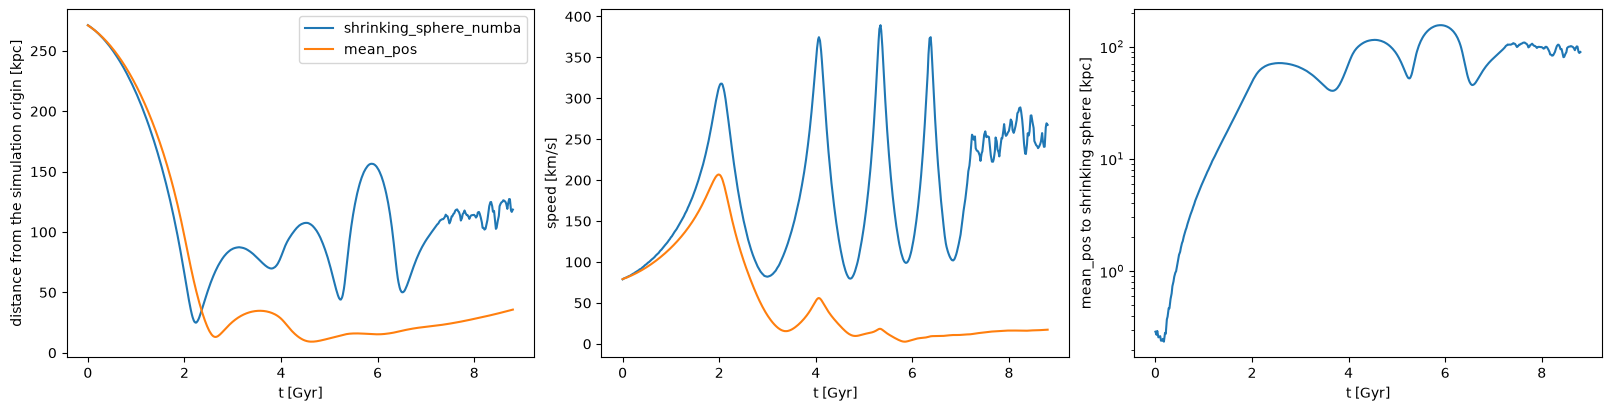

In [5]:
t = ss["t"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for m, o in orbits.items():
    pos = np.c_[o["x"], o["y"], o["z"]]
    vel = np.c_[o["vx"], o["vy"], o["vz"]]
    ax[0].plot(t, np.linalg.norm(pos, axis=1), label=m)
    ax[1].plot(t, np.linalg.norm(vel, axis=1), label=m)
offset = np.linalg.norm(np.c_[orbits["mean_pos"]["x"] - ss["x"], orbits["mean_pos"]["y"] - ss["y"],
                              orbits["mean_pos"]["z"] - ss["z"]], axis=1)
ax[2].semilogy(t, offset)
ax[0].set_ylabel("distance from the simulation origin [kpc]")
ax[1].set_ylabel("speed [km/s]")
ax[2].set_ylabel("mean_pos to shrinking sphere [kpc]")
for a in ax:
    a.set_xlabel("t [Gyr]")
ax[0].legend()
plt.show()

## When is the center reliable?

The LMC is disrupted by the MW. The diagnostics of the shrinking sphere show when its core dissolves: the
final sphere grows and its density falls, and the step between snapshots stops matching the velocity
(`velocity_error`, $|\Delta x - v\,\Delta t| / (|v|\,\Delta t)$). Once the density is below about 1% of its
initial value there is no bound core left, and the center should not be trusted.

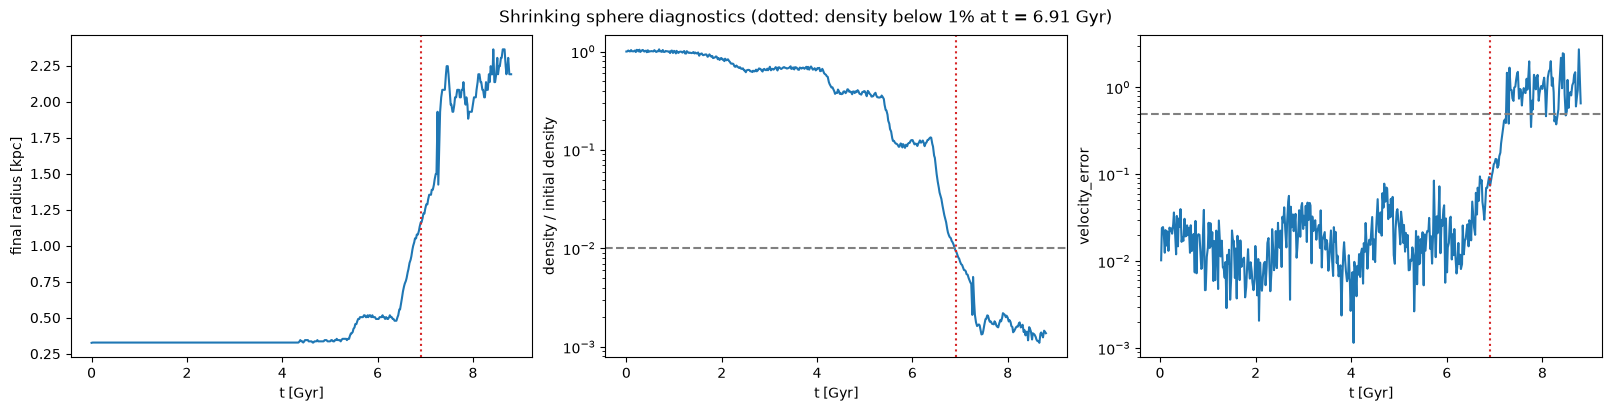

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
ax[0].plot(t, ss["radius"])
ax[0].set_ylabel("final radius [kpc]")
ax[1].semilogy(t, ss["density_ratio"])
ax[1].axhline(0.01, c="0.5", ls="--")
ax[1].set_ylabel("density / initial density")
ax[2].semilogy(t, ss["velocity_error"])
ax[2].axhline(0.5, c="0.5", ls="--")
ax[2].set_ylabel("velocity_error")
gone = t[np.argmax(ss["density_ratio"] < 0.01)]
for a in ax:
    a.axvline(gone, c="C3", ls=":")
    a.set_xlabel("t [Gyr]")
fig.suptitle(f"Shrinking sphere diagnostics (dotted: density below 1% at t = {gone:.2f} Gyr)")
plt.show()

## Projected density around each center

For a few snapshots, the LMC particles are shifted to the center found by each method and projected on the
y-z plane. The cross marks the center.

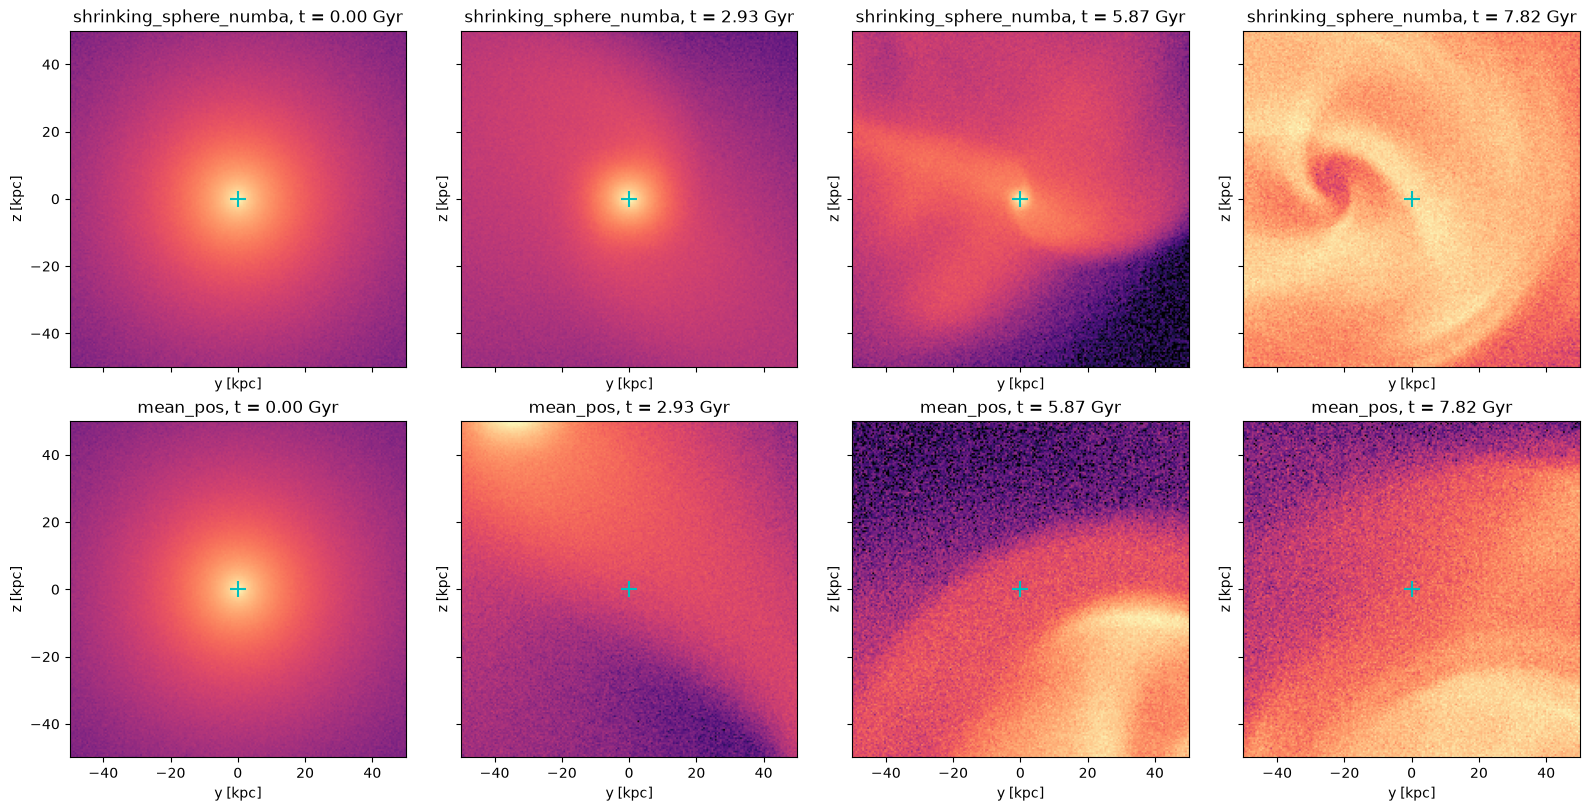

In [7]:
show = [0, 150, 300, 400]
box, nbins = 50, 200
fig, ax = plt.subplots(len(methods), len(show), figsize=(4 * len(show), 4 * len(methods)),
                       sharex=True, sharey=True, constrained_layout=True)
for c, k in enumerate(show):
    lmc_pos = ReadGC21(path, snapname.format(k)).read_halo(["pos"], halo="LMC", ptype="dm")["pos"]
    for r, m in enumerate(methods):
        row = orbits[m][orbits[m]["snap"] == k][0]
        shifted = lmc_pos - [row["x"], row["y"], row["z"]]
        h, _, _ = np.histogram2d(shifted[:, 1], shifted[:, 2], bins=nbins, range=[[-box, box], [-box, box]])
        ax[r, c].imshow(h.T, origin="lower", extent=[-box, box, -box, box], norm=LogNorm(vmin=1), cmap=CMAP)
        ax[r, c].plot(0, 0, "c+", ms=12, mew=1.5)
        ax[r, c].set_title(f"{m}, t = {row['t']:.2f} Gyr")
        ax[r, c].set_xlabel("y [kpc]")
        ax[r, c].set_ylabel("z [kpc]")
    del lmc_pos
plt.show()